# 28 Jan

In [ ]:
!nvidia-smi
!pip install numba

Wed Jan 28 12:18:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import numpy as np
from numba import cuda

In [ ]:
@cuda.jit
def hello_kernel():
    # Thread and block indices
    tx = cuda.threadIdx.x
    bx = cuda.blockIdx.x
    bdim = cuda.blockDim.x

    # Global thread ID
    gid = bx * bdim + tx

    print("Hello from Block", bx, "Thread", tx, "Global ID", gid)
blocks = 512
threads_per_block = 128

# Launch kernel
hello_kernel[blocks, threads_per_block]()

# Synchronize GPU
cuda.synchronize()

In [ ]:
import numpy as np
from numba import cuda

@cuda.jit
def vector_add(a, b, c):
    # Global thread index
    idx = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    # Boundary check
    if idx < a.size:
        c[idx] = a[idx] + b[idx]

In [ ]:
# Input size
n = 10_000

# Host arrays (CPU)
a = np.arange(n, dtype=np.float32)
b = np.arange(n, dtype=np.float32)

# Device arrays (GPU)
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)
d_c = cuda.device_array(n, dtype=np.float32)

# Kernel launch configuration
threads_per_block = 256
blocks = (n + threads_per_block - 1) // threads_per_block

# Launch kernel
vector_add[blocks, threads_per_block](d_a, d_b, d_c)

# Copy result back to host
c = d_c.copy_to_host()

print(c[:10])


[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


# 04 Feb

In [ ]:
# Multiplication
!pip install numba
import numpy as np
from numba import cuda

# -------------------------------
# CUDA Kernel
# -------------------------------
@cuda.jit
def add_arrays(a, b, c):
    i = cuda.grid(1)   # Global thread index
    if i < a.size:
        c[i] = a[i] + b[i]

# -------------------------------
# Host Code
# -------------------------------
n = 1024

# Create input arrays on CPU
a = np.arange(n, dtype=np.float32)
b = np.arange(n, dtype=np.float32)

# Allocate output array on CPU
c = np.zeros(n, dtype=np.float32)

# Copy arrays to GPU
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)
d_c = cuda.to_device(c)

# CUDA configuration
threads_per_block = 256
blocks_per_grid = (n + threads_per_block - 1) // threads_per_block

# Launch kernel
add_arrays[blocks_per_grid, threads_per_block](d_a, d_b, d_c)

# Copy result back to CPU
c = d_c.copy_to_host()

# Print result
print("First 10 results:", c[:10])


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


First 10 results: [ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]


In [ ]:
from numba import cuda
print(cuda.gpus)


<Managed Device <CUdevice 0>>


In [ ]:
add_arrays[blocks_per_grid, threads_per_block](d_a, d_b, d_c)

In [1]:
# CUDA Kernel for Element wise addition
from numba import cuda
import numpy as np

@cuda.jit
def add_matrices(a, b, c, n, m):
    i, j = cuda.grid(2)
    if i < n and j < m:
        c[i, j] = a[i, j] * b[i, j]

def main():
    n = 6
    m = 6
    a = np.arange(n * m, dtype=np.int32).reshape((n, m))
    b = np.arange(n * m, dtype=np.int32).reshape((n, m))
    c = np.zeros((n, m), dtype=np.int32)
    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)
    d_c = cuda.to_device(c)
    threads_per_block = (6, 6)
    blocks_per_grid = ((n + threads_per_block[0] - 1),
                       (m + threads_per_block[1] - 1))
    add_matrices[blocks_per_grid, threads_per_block](d_a, d_b, d_c, n, m)
    cuda.synchronize()
    c = d_c.copy_to_host()
    print("First 10 rows and columns of the result:")
    print(c[:10, :10])

if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 121 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


First 10 rows and columns of the result:
[[   0    1    4    9   16   25]
 [  36   49   64   81  100  121]
 [ 144  169  196  225  256  289]
 [ 324  361  400  441  484  529]
 [ 576  625  676  729  784  841]
 [ 900  961 1024 1089 1156 1225]]


# 11 Feb

In [ ]:
#RGB to grayscale, G=0.299R + 0.587G +0.114B, using GPU and CPU, show time difference

In [ ]:
!pip install cupy-cuda12x

Image shape: (2160, 3840, 3)
CPU Time: 103.032 ms
GPU Time: 1091.386 ms


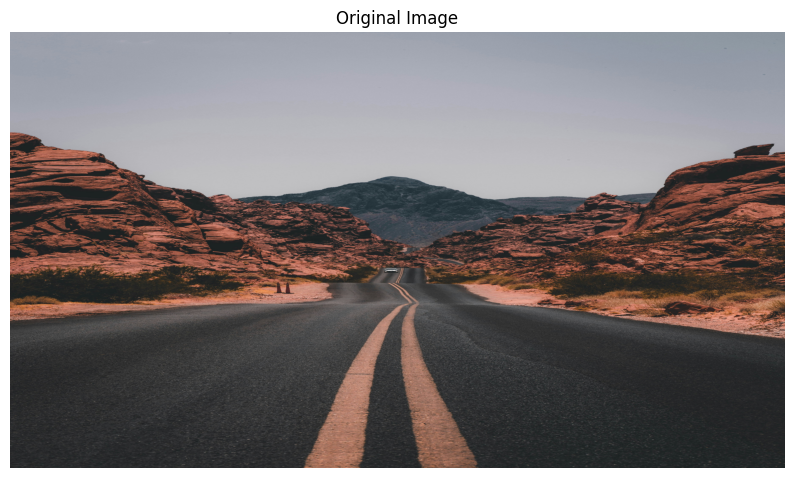

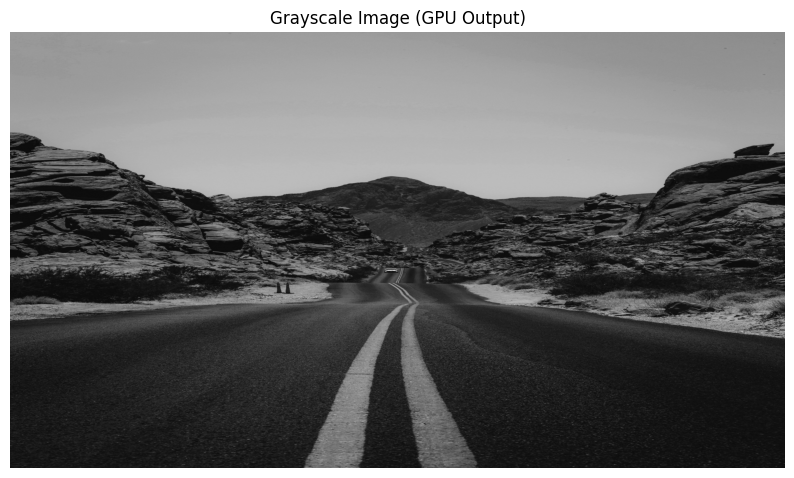

Time Difference (CPU - GPU): -988.354 ms
Speedup: 0.09 x


In [ ]:
import numpy as np
import cupy as cp
import cv2
import time
import urllib.request
import matplotlib.pyplot as plt

# Download a 4K Image
url = "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee"

urllib.request.urlretrieve(url, "4k.jpg")

img = cv2.imread("4k.jpg")
img = cv2.resize(img, (3840, 2160))  # Ensure exact 4K

print("Image shape:", img.shape)

# CPU Grayscale
start_cpu = time.time()

gray_cpu = (0.299 * img[:,:,2] +
            0.587 * img[:,:,1] +
            0.114 * img[:,:,0]).astype(np.uint8)

end_cpu = time.time()
cpu_time = (end_cpu - start_cpu) * 1000

print("CPU Time: %.3f ms" % cpu_time)

# GPU Grayscale
img_gpu = cp.asarray(img)

start_gpu = cp.cuda.Event()
end_gpu = cp.cuda.Event()

start_gpu.record()

gray_gpu = (0.299 * img_gpu[:,:,2] +
            0.587 * img_gpu[:,:,1] +
            0.114 * img_gpu[:,:,0]).astype(cp.uint8)

end_gpu.record()
end_gpu.synchronize()

gpu_time = cp.cuda.get_elapsed_time(start_gpu, end_gpu)

print("GPU Time: %.3f ms" % gpu_time)

# Bring GPU result back to CPU
gray_from_gpu = cp.asnumpy(gray_gpu)

# Save Output Image
cv2.imwrite("gray_output.jpg", gray_from_gpu)

# Display Grayscale Image
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(gray_from_gpu, cmap='gray')
plt.title("Grayscale Image (GPU Output)")
plt.axis("off")
plt.show()

# Performance Comparison
print("Time Difference (CPU - GPU): %.3f ms" % (cpu_time - gpu_time))
print("Speedup: %.2f x" % (cpu_time / gpu_time))

In [ ]:
print(f"Image size (width, height): {img.size} pixels")

Image size (width, height): 24883200 pixels


In [ ]:
print(f"Height: {img.shape[0]}")
print(f"Width: {img.shape[1]}")
print(f"Channels: {img.shape[2]}")
print(f"Shape (H, W, C): {img.shape}")

Height: 2160
Width: 3840
Channels: 3
Shape (H, W, C): (2160, 3840, 3)


# 18 Feb

Implement CNN, Conv2D (5x5, 32 filters) → ReLU → Downsampling → FC → Sigmoid
make kernel, so no torch

In [2]:
import numpy as np
from numba import cuda, float32
import math


 #Convolution Layer

@cuda.jit
def conv2d_kernel(image, kernel, output):
    i, j = cuda.grid(2)

    k_h = kernel.shape[0]
    k_w = kernel.shape[1]

    if i < output.shape[0] and j < output.shape[1]:
        s = 0.0
        for m in range(k_h):
            for n in range(k_w):
                s += image[i + m, j + n] * kernel[m, n]
        output[i, j] = s


# ReLU Activation

@cuda.jit
def relu_kernel(x):
    i = cuda.grid(1)
    if i < x.size:
        if x[i] < 0:
            x[i] = 0



# Max Pooling 2x2

@cuda.jit
def maxpool_kernel(image, output):
    i, j = cuda.grid(2)

    if i < output.shape[0] and j < output.shape[1]:
        r = i * 2
        c = j * 2

        m = image[r, c]
        if image[r, c+1] > m: m = image[r, c+1]
        if image[r+1, c] > m: m = image[r+1, c]
        if image[r+1, c+1] > m: m = image[r+1, c+1]

        output[i, j] = m



# Dense Layer

@cuda.jit
def dense_kernel(x, weights, bias, output):
    i = cuda.grid(1)

    if i < output.size:
        s = 0.0
        for j in range(x.size):
            s += x[j] * weights[j, i]
        output[i] = s + bias[i]



# Sigmoid Activation

@cuda.jit
def sigmoid_kernel(x):
    i = cuda.grid(1)
    if i < x.size:
        x[i] = 1 / (1 + math.exp(-x[i]))

In [3]:
# dummy image 28x28
image = np.random.rand(28, 28).astype(np.float32)
kernel = np.random.rand(3, 3).astype(np.float32)

# allocate GPU memory
d_image = cuda.to_device(image)
d_kernel = cuda.to_device(kernel)
conv_out = cuda.device_array((26, 26), dtype=np.float32)

# launch convolution
threads = (16, 16)
blocks = (2, 2)
conv2d_kernel[blocks, threads](d_image, d_kernel, conv_out)

# ReLU
relu_kernel[256, 256](conv_out.reshape(-1))

# Max pooling
pool_out = cuda.device_array((13, 13), dtype=np.float32)
maxpool_kernel[blocks, threads](conv_out, pool_out)

# Flatten
flat = pool_out.copy_to_host().reshape(-1).astype(np.float32)
d_flat = cuda.to_device(flat)

# Dense layer
weights = np.random.rand(flat.size, 1).astype(np.float32)
bias = np.array([0.1], dtype=np.float32)

d_weights = cuda.to_device(weights)
d_bias = cuda.to_device(bias)
dense_out = cuda.device_array(1, dtype=np.float32)

dense_kernel[1, 1](d_flat, d_weights, d_bias, dense_out)

# Sigmoid
sigmoid_kernel[1, 1](dense_out)

result = dense_out.copy_to_host()
print("Prediction:", result)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Prediction: [1.]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [4]:
import numpy as np

def generate_synthetic_face(size=(28, 28)):
    """
    Generates a 28x28 grayscale numpy array representing a simple face-like pattern
    (e.g., a Gaussian blob). Values are in the range [0, 1].
    """
    x = np.linspace(-1, 1, size[1])
    y = np.linspace(-1, 1, size[0])
    X, Y = np.meshgrid(x, y)

    # Create a central Gaussian blob for the 'face'
    face_pattern = np.exp(-(X**2 + Y**2) / 0.5)

    # Add a slight asymmetry or other features for variation
    # For simplicity, we keep it a smooth blob here. Additional features can be added.

    # Normalize to [0, 1]
    face_pattern = (face_pattern - face_pattern.min()) / (face_pattern.max() - face_pattern.min())

    return face_pattern.astype(np.float32)

print("Defined generate_synthetic_face function.")

Defined generate_synthetic_face function.


In [5]:
def apply_mask(image):
    """
    Applies a black rectangular mask to the lower half of a 28x28 grayscale image.
    The mask is simulated by setting pixel values to 0 in a specific region.
    """
    masked_image = np.copy(image)
    # Define the mask region: lower half of the image
    # For a 28x28 image, start masking from row 14 to the end.
    mask_start_row = image.shape[0] // 2
    masked_image[mask_start_row:, :] = 0.0  # Set pixel values to 0 (black)
    return masked_image.astype(np.float32)

print("Defined apply_mask function.")

Defined apply_mask function.


In [6]:
simulated_images = []
simulated_labels = []

# Generate unmasked face images
for i in range(2):
    face = generate_synthetic_face()
    simulated_images.append(face)
    simulated_labels.append('unmasked')
    print(f"Generated unmasked face image {i+1} with shape {face.shape} and dtype {face.dtype}")

# Generate masked face images
for i in range(2):
    face = generate_synthetic_face()
    masked_face = apply_mask(face)
    simulated_images.append(masked_face)
    simulated_labels.append('masked')
    print(f"Generated masked face image {i+1} with shape {masked_face.shape} and dtype {masked_face.dtype}")

print(f"Total simulated images: {len(simulated_images)}")
print(f"Total simulated labels: {len(simulated_labels)}")

Generated unmasked face image 1 with shape (28, 28) and dtype float32
Generated unmasked face image 2 with shape (28, 28) and dtype float32
Generated masked face image 1 with shape (28, 28) and dtype float32
Generated masked face image 2 with shape (28, 28) and dtype float32
Total simulated images: 4
Total simulated labels: 4


In [7]:
predictions = []

# Define blocks and threads based on previous usage, adjusting for new output sizes where necessary
threads_per_block_2d = (16, 16) # For 2D kernels like conv2d and maxpool
threads_per_block_1d = 256    # For 1D kernels like relu

for i, image in enumerate(simulated_images):
    # 3a. Transfer the image to the GPU
    d_image = cuda.to_device(image)

    # 3b. Define kernel and output dimensions for convolution layer (28x28 input -> 26x26 output with 3x3 kernel)
    conv_out_shape = (image.shape[0] - kernel.shape[0] + 1, image.shape[1] - kernel.shape[1] + 1)
    conv_out = cuda.device_array(conv_out_shape, dtype=np.float32)

    # Determine blocks for conv2d_kernel
    blocks_conv = (math.ceil(conv_out_shape[0] / threads_per_block_2d[0]),
                   math.ceil(conv_out_shape[1] / threads_per_block_2d[1]))

    # 3c. Launch the conv2d_kernel
    conv2d_kernel[blocks_conv, threads_per_block_2d](d_image, d_kernel, conv_out)

    # 3d. Apply ReLU activation
    relu_input_size = conv_out.size
    blocks_relu = (relu_input_size + threads_per_block_1d - 1) // threads_per_block_1d
    relu_kernel[blocks_relu, threads_per_block_1d](conv_out.reshape(-1))

    # 3e. Define output dimensions for max pooling (26x26 input -> 13x13 output with 2x2 pooling)
    pool_out_shape = (conv_out_shape[0] // 2, conv_out_shape[1] // 2)
    pool_out = cuda.device_array(pool_out_shape, dtype=np.float32)

    # Determine blocks for maxpool_kernel
    blocks_maxpool = (math.ceil(pool_out_shape[0] / threads_per_block_2d[0]),
                      math.ceil(pool_out_shape[1] / threads_per_block_2d[1]))

    # 3f. Launch the maxpool_kernel
    maxpool_kernel[blocks_maxpool, threads_per_block_2d](conv_out, pool_out)

    # 3g. Flatten the pooled output
    flat = pool_out.copy_to_host().reshape(-1).astype(np.float32)
    d_flat = cuda.to_device(flat)

    # 3h. Perform the Dense layer calculation. (Output is a single neuron)
    # Ensure weights and bias are compatible. weights should be (flat.size, 1)
    # d_weights and d_bias were already defined in previous cells.
    dense_out = cuda.device_array(1, dtype=np.float32)

    # 3i. Launch the dense_kernel
    dense_kernel[1, 1](d_flat, d_weights, d_bias, dense_out)

    # 3j. Apply Sigmoid activation
    sigmoid_kernel[1, 1](dense_out)

    # 3k. Copy the final prediction back to the host and append to predictions list
    result = dense_out.copy_to_host()
    predictions.append(result[0])
    print(f"Processed image {i+1} ({simulated_labels[i]}): Prediction = {result[0]:.4f}")

print("\nAll images processed. Predictions:", predictions)

Processed image 1 (unmasked): Prediction = 1.0000
Processed image 2 (unmasked): Prediction = 1.0000
Processed image 3 (masked): Prediction = 1.0000
Processed image 4 (masked): Prediction = 1.0000

All images processed. Predictions: [np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0)]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


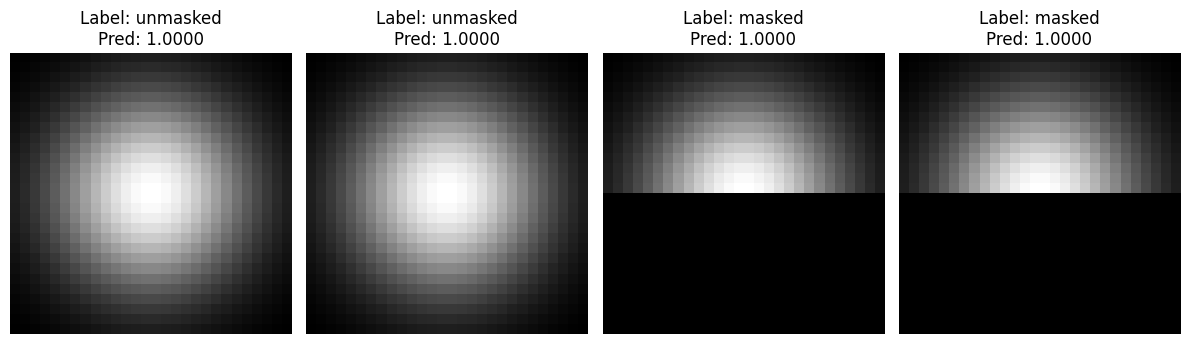

In [8]:
import matplotlib.pyplot as plt

# Visualize a few samples
num_samples_to_visualize = min(len(simulated_images), 4) # Visualize up to 4 images

plt.figure(figsize=(12, 8))
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    plt.imshow(simulated_images[i], cmap='gray')
    title = f"Label: {simulated_labels[i]}\nPred: {predictions[i]:.4f}"
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 25 Feb

WAP to perform Bitonic sorting

In [9]:
import numpy as np
from numba import cuda

@cuda.jit
def bitonic_sort_step(values, j, k):
    i = cuda.grid(1)

    if i < values.size:
        ixj = i ^ j

        if ixj > i:
            # Ascending order
            if (i & k) == 0:
                if values[i] > values[ixj]:
                    temp = values[i]
                    values[i] = values[ixj]
                    values[ixj] = temp
            # Descending order
            else:
                if values[i] < values[ixj]:
                    temp = values[i]
                    values[i] = values[ixj]
                    values[ixj] = temp


def bitonic_sort_gpu(arr):
    n = arr.size

    d_arr = cuda.to_device(arr)

    threads_per_block = 256
    blocks = (n + threads_per_block - 1) // threads_per_block

    k = 2
    while k <= n:
        j = k >> 1
        while j > 0:
            bitonic_sort_step[blocks, threads_per_block](d_arr, j, k)
            cuda.synchronize()
            j >>= 1
        k <<= 1

    return d_arr.copy_to_host()


if __name__ == "__main__":
    arr = np.array([3, 7, 4, 8, 6, 2, 1, 5], dtype=np.int32)

    print("Original array:")
    print(arr)

    sorted_arr = bitonic_sort_gpu(arr)

    print("Sorted array:")
    print(sorted_arr)

Original array:
[3 7 4 8 6 2 1 5]
Sorted array:
[1 2 3 4 5 6 7 8]
